# 5 · Choropleth, shapes & map decoration

Vector-polygon rendering and map context:

- `choropleth` — fill polygons by an attribute column (cleopatra `PolygonGlyph`).
- `shapes` — draw polygon outlines only.
- `set_domain` — crop the view to a named region (e.g. `"europe"`), reprojected via pyramids.
- `coastlines` / `borders` / `land` / `ocean` — Natural Earth vector context from `pyramids.basemap`.

The polygons here are the DEM's own cells, vectorised by pyramids and coloured by elevation. Natural-Earth overlays need network access, so they are wrapped in `try/except` and the view is always clipped to the data (a global layer never blows the zoom out to the whole world).

**Setup.** Inline plots + resolve the DEM path.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample DEM is found whether this runs from
# docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
print("DEM:", DEM)

DEM: C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\examples\data\LisbonElevation.tif


Resample the DEM coarse, **vectorise its cells** to polygons with pyramids' `get_cell_polygons`, and attach the per-cell elevation as the value column the choropleth will colour by.

In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalearth.scene import Map

ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 12)   # coarse cells -> polygon features
# vectorise the cells (pyramids) and attach the per-cell elevation as the value column
cells = coarse.get_cell_polygons()
cells['elevation'] = coarse.read_array(band=0).astype('float64').ravel()
print('polygons:', len(cells))

polygons: 1610


## choropleth — polygons coloured by elevation

**choropleth** — fill each polygon by its `elevation` value (cleopatra `PolygonGlyph`), with an aggregated colorbar.

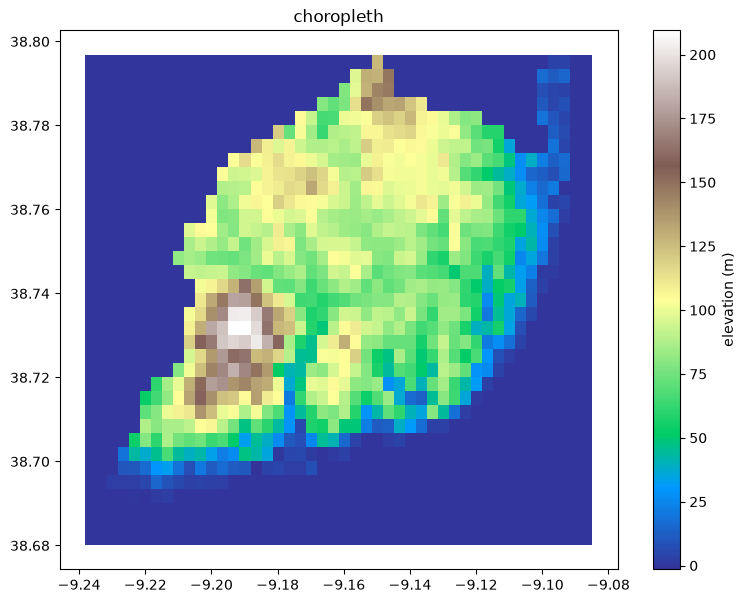

In [3]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.choropleth(cells, column='elevation', cmap='terrain')
m.colorbar(label='elevation (m)')
m.set_title('choropleth')
m.fig;

## shapes — outlines only

**shapes** — the same polygons drawn as outlines only (no fill), e.g. for administrative or mesh boundaries.

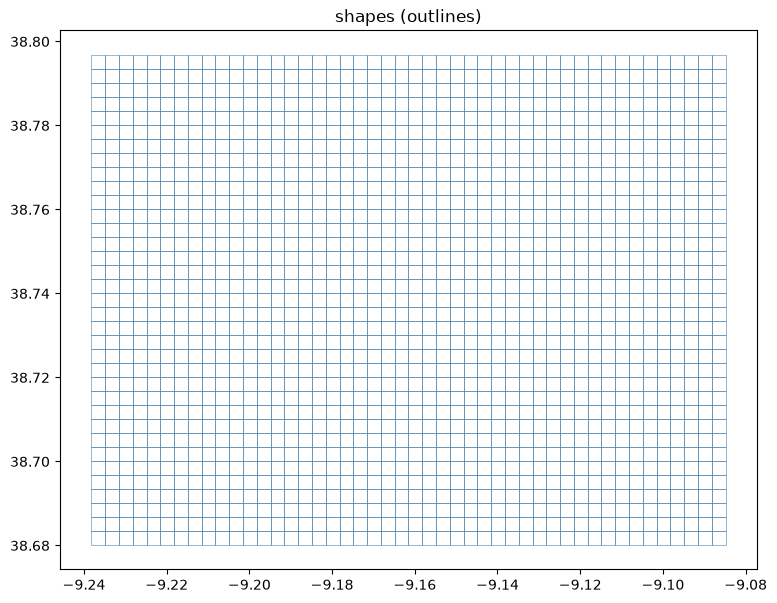

In [4]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.shapes(cells, edgecolor='steelblue', linewidth=0.4)
m.set_title('shapes (outlines)')
m.fig;

## Named domains (extent from a region, reprojected via pyramids)

**Named domains** — draw Natural Earth land/coastlines/borders for context, then `set_domain('europe')` crops the view to that region (reprojected to the display CRS via pyramids). The global layers are clipped to the domain, not zoomed out to the whole world.

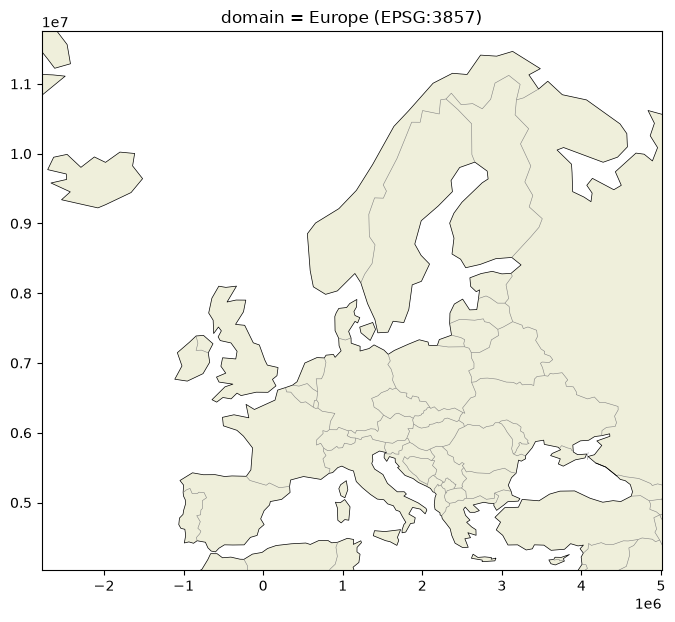

In [5]:
m = Map(crs=3857, figsize=(8, 7))
# draw Natural Earth context, then crop the view to the named region
for name in ('land', 'coastlines', 'borders'):
    try:
        getattr(m, name)(resolution='110m')
    except Exception as exc:
        print(f'{name}: unavailable offline ({type(exc).__name__})')
m.set_domain('europe')
m.set_title('domain = Europe (EPSG:3857)')
m.fig;

## DEM + coastlines / borders (need network — guarded)

**Decoration** — overlay coastlines and borders on the DEM. They are fetched from Natural Earth (network), so the calls are guarded; the view stays clipped to the DEM's extent.

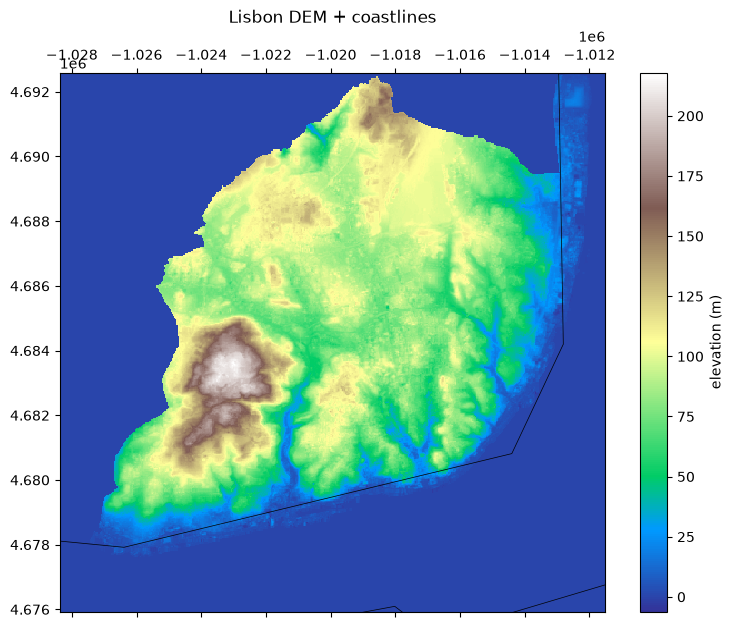

In [6]:
m = Map(crs=3857, figsize=(9, 7))
m.imshow(ds, cmap='terrain')
for name in ('coastlines', 'borders'):
    try:
        getattr(m, name)(resolution='10m')
    except Exception as exc:
        print(f'{name}: unavailable offline ({type(exc).__name__})')
m.colorbar(label='elevation (m)')
m.set_title('Lisbon DEM + coastlines')
m.fig;